<a href="https://colab.research.google.com/github/LakshmiAhala/MachineLearning/blob/main/ML_Assign10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Important imports

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np

#Part1: Data Exploration

1) Load the breast-cancer.csv dataset
2) Display basic information (shape, columns, data types)
3) Check for missing values
4) Display the class distribution (how many M vs. B)
5) Show summary statistics for features

In [ ]:
# Loading the dataset

print("###Loading the Dataset###")
import pandas as pd
df = pd.read_csv('breast-cancer.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head(5))

# Displaying basic information (shape, columns, data types)
print("\n###Displaying Basic Information###")
print("Shape of the DataFrame:", df.shape)
print("\nColumn names:", df.columns)
print("\nData types of columns:\n", df.dtypes)

# Displaying missing values
print("\n###Displaying Missing Values###")
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Displaying class distribution
print("\n###Displaying Class Distribution###")
class_distribution = df['diagnosis'].value_counts()
print("Class distribution (M vs. B):\n", class_distribution)

# Displaying summary statistics
print("\n###Displaying Summary Statistics###")
summary_statistics = df.describe()
print("Summary statistics for numerical features:\n", summary_statistics)

###Loading the Dataset###
Dataset loaded successfully. Displaying the first 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



###Displaying Basic Information###
Shape of the DataFrame: (569, 32)

Column names: Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Data types of columns:
 id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            flo

#Part2: Data Preparation

1) Separate features (X) and target (y)
2) Encode the target variable if needed (M=1, B=0 or use LabelEncoder)
3) Split data into training (70%) and testing (30%) sets
4) Use random_state=42 for reproducibility


In [ ]:
# Dropping id as it doesnt hold any significance
X = df.drop(columns=['id', 'diagnosis'])

# Assigning diagnosis as the target variable
y = df['diagnosis']

# Confirming the dimensions of X and y
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Encoding and mapping M & B to 1, 0
y_encoded = y.map({'M': 1, 'B': 0})

# Ensuring the numbers are the same
print("Original target distribution:\n", y.value_counts())
print("\nEncoded target distribution:\n", y_encoded.value_counts())

# Splitting into training and testing data --> 70% and 30%
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining set target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest set target distribution:\n", y_test.value_counts(normalize=True))

Features (X) shape: (569, 30)
Target (y) shape: (569,)
Original target distribution:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Encoded target distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64
X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)

Training set target distribution:
 diagnosis
0    0.628141
1    0.371859
Name: proportion, dtype: float64

Test set target distribution:
 diagnosis
0    0.625731
1    0.374269
Name: proportion, dtype: float64


# Part3: Build Decision Tree Models (8 points)
1) Create a baseline decision tree with default parameters
2) Train the model on training data
3) Make predictions on test data
4) Calculate and display: Accuracy score, Confusion Matrix,   Classification report (precision, recall, f1-score), Build improved models with different hyperparameters:

Model with max_depth=3

Model with max_depth=5

Model with max_depth=10

Model with min_samples_split=20

5) Compare accuracies and identify which performs best

In [ ]:
# Baseline Decision Tree Model (Default Parameters)
print("\n--- Baseline Decision Tree Model (Default Parameters) ---")
baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)

y_pred_baseline = baseline_dt.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred_baseline))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_baseline))
print("\nClassification Report:\n", classification_report(y_test, y_pred_baseline))

# Improved Models with Different Hyperparameters
print("\n--- Improved Decision Tree Models ---")

models = {
    "max_depth=3": DecisionTreeClassifier(max_depth=3, random_state=42),
    "max_depth=5": DecisionTreeClassifier(max_depth=5, random_state=42),
    "max_depth=10": DecisionTreeClassifier(max_depth=10, random_state=42),
    "min_samples_split=20": DecisionTreeClassifier(min_samples_split=20, random_state=42)
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"Model: {name}, Accuracy: {acc:.4f}")

# Compare Accuracies and Identify Best Performer
print("\n--- Comparison of Model Accuracies ---")

# Include baseline accuracy in comparison
accuracies["Baseline (Default)"] = accuracy_score(y_test, y_pred_baseline)

best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]

for name, acc in accuracies.items():
    print(f"  {name}: {acc:.4f}")

print(f"\nThe best performing model is '{best_model_name}' with an accuracy of {best_accuracy:.4f}.")


--- Baseline Decision Tree Model (Default Parameters) ---
Accuracy Score: 0.9005847953216374

Confusion Matrix:
 [[100   7]
 [ 10  54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       107
           1       0.89      0.84      0.86        64

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171


--- Improved Decision Tree Models ---
Model: max_depth=3, Accuracy: 0.9181
Model: max_depth=5, Accuracy: 0.9064
Model: max_depth=10, Accuracy: 0.9006
Model: min_samples_split=20, Accuracy: 0.9123

--- Comparison of Model Accuracies ---
  max_depth=3: 0.9181
  max_depth=5: 0.9064
  max_depth=10: 0.9006
  min_samples_split=20: 0.9123
  Baseline (Default): 0.9006

The best performing model is 'max_depth=3' with an accuracy of 0.9181.


# Part4: Visualization

1) Visualize your best decision tree using plot_tree()



*   Make it readable (large figure size)
*   Include feature names
*   Include class names (Malignant, Benign)
*   Use filled=True for colored boxes

2) Create a feature importance bar chart

*   Show top 10 most important features
*   Sort from highest to lowest importance


Visualizing the best model: max_depth=3


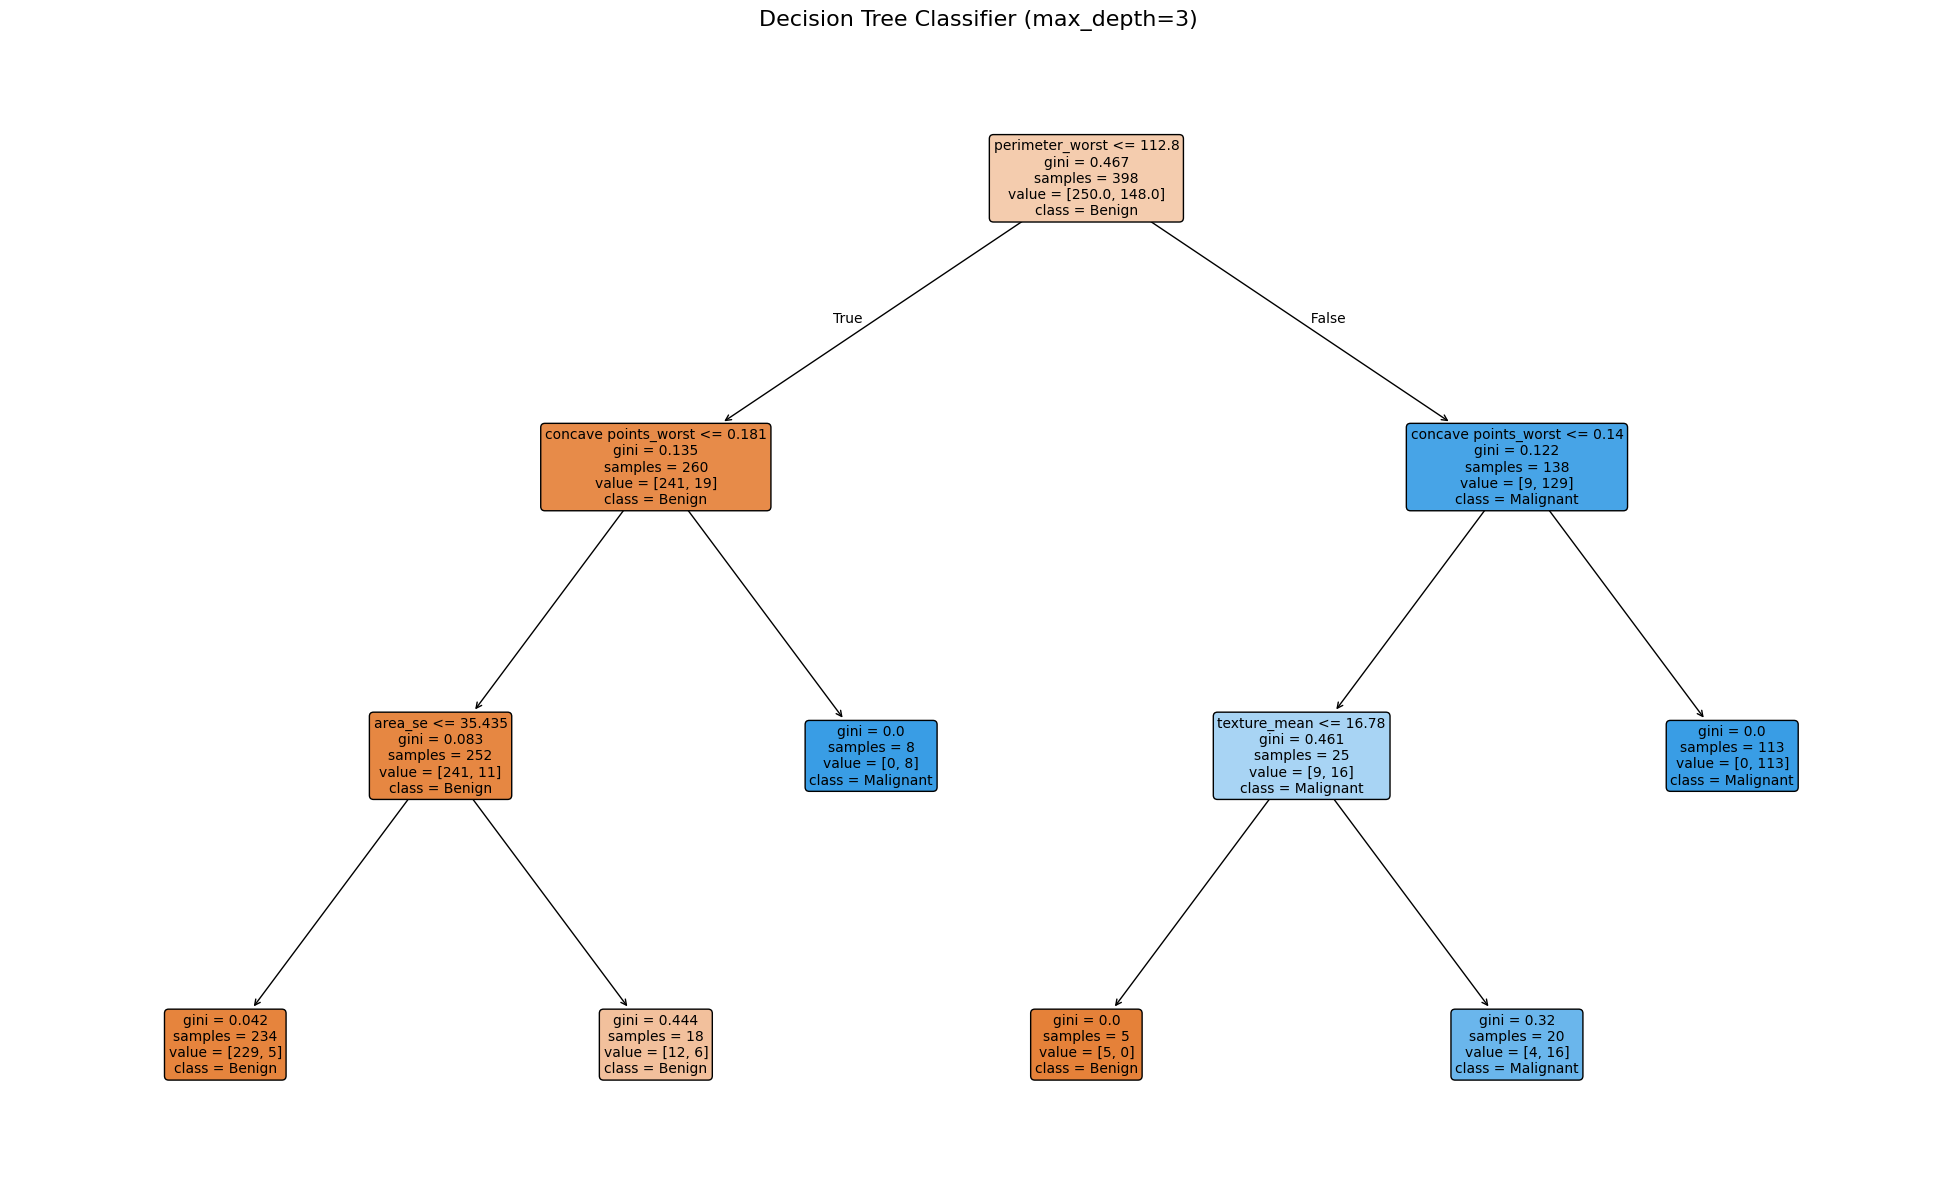


--- Feature Importance Bar Chart ---


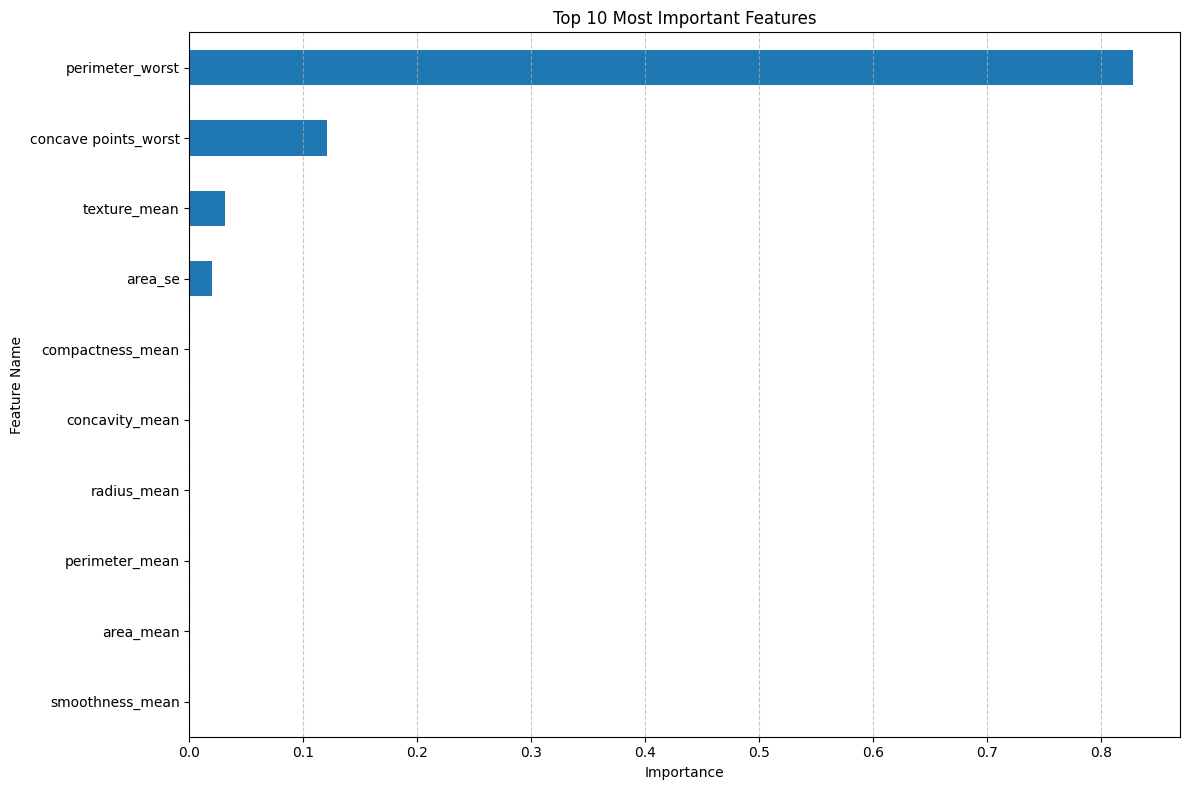

In [ ]:
# Retrieving the best model and its name
best_model_name = max(accuracies, key=accuracies.get)
best_dt_model = models[best_model_name]

print(f"Visualizing the best model: {best_model_name}")

# Defining feature names and class names for plotting
feature_names = X.columns.tolist()
class_names = ['Benign', 'Malignant'] # 0: Benign (B), 1: Malignant (M)

# --- Visualizing the Best Decision Tree ---
plt.figure(figsize=(25, 15)) # Set a large figure size for readability
plot_tree(best_dt_model,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title(f'Decision Tree Classifier ({best_model_name})', fontsize=16)
plt.show()

# --- Creating a Feature Importance Bar Chart ---
print("\n--- Feature Importance Bar Chart ---")

# Getting feature importances from the best model
importances = best_dt_model.feature_importances_

# Creating a pandas Series for easier sorting and selection
feature_importances = pd.Series(importances, index=feature_names)

# Sort features by importance in descending order and get top 10
top_10_features = feature_importances.nlargest(10)

# Plotting the top 10 feature importances
plt.figure(figsize=(12, 8))
top_10_features.sort_values(ascending=True).plot(kind='barh') # sort_values for clean bar chart
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Part5: Analysis
1) Which hyperparameter setting worked best and why?

-- The hyperparameter setting max_depth=3 had the best accuracy providing a good balance and capturing important patterns without becoming overly complex.

2) What are the top 3 most important features for prediction?

-- permeter_worst, concave_points_worst, and texture_mean

3) Did you observe any overfitting? How can you tell?

-- As the max_depth increases more than 3, the accuracy decreased. This means that the deeper trees have more noise from the training data.

4) How confident would you be using this model in a real medical setting?

-- While the accuracy of the model is good, I would still be a bit apprehensive about using this in a real medical setting. Medical situations like cancer diagnosis typically require more extensive research, higher accuracy with diverse datasets, and expert advice to arrive at a conclusion.
Personally, I would take the opinion/decision of the model into consideration, and then check other factors manually to see if the result matches or not.